# Imports

In [1]:
import os
import h5py
import numpy as np
from scipy.stats import mode, sem
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Functions

### Visualization of features

In [ ]:
def visualize_features(average_dict, error_dict, feature_name, feature_index, colors, state_names, title_id, file_id):
    states = [0, 1, 2, 3, 4]
    mean_values = [average_dict[state][feature_index] for state in states]
    error_values = [error_dict[state][feature_index] for state in states]

    plt.figure(figsize=(7, 5))
    plt.bar(states, mean_values, color=[colors[int(s)] for s in states], yerr=error_values, capsize=5, edgecolor='black', alpha=0.6, zorder=2)
    plt.xticks(states, state_names)
    plt.ylabel('Mean values')
    plt.xlabel('Sleep states')
    if feature_name in ['aperiodic', 'dfa', 'mse']:
        plt.ylim(-1.1, 1.1)
    else:
        plt.ylim(-0.1, 1.1)
    plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
    plt.title(f'Average of feature {feature_name} - {title_id}')
    plt.savefig(os.path.join(output, 'barplots', f'{file_id}_{feature_name}_barplot.svg'), format="svg")
    plt.show()

In [ ]:
def features_violin(df, feature_name, state_id, state_names, colors, title_id, file_id):
    plt.figure(figsize=(7, 5))
    sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)
    sns.stripplot(x='State', y='Value', data=df, color='black', alpha=0.5, zorder=1, marker='D', size=4, jitter=0.25)
    plt.title(f"Distribution of {feature_name} per state - {title_id}")
    plt.ylabel(f"Normalized {feature_name} value")
    plt.xticks(state_id, state_names)
    plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
    if feature_name in ['aperiodic', 'dfa', 'mse']:
        plt.ylim(-1.1, 1.1)
    else:
        plt.ylim(-0.1, 1.1)
    plt.savefig(os.path.join(output, 'violinplots', f'{file_id}_{feature_name}_violinplot.svg'), format="svg")
    plt.show()

# Input paths and static variables

### Static variables

In [ ]:
epoch_length = 10
fs = 250
feature_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
file_id = 'sleep-edf'
title_id = 'Sleep-EDF'

### Static paths

In [5]:
h5_file = r"D:\dilon_data\MOTORWP4_dataset\hdf5\motorwp4_fpz-cz_pz-oz.h5"
output = r"D:\dilon_data\visualization_collection\filtered_sleep-edf"

# Main workflow

### open HDF5 file

In [6]:
h5 = h5py.File(h5_file, 'r')

### Get averages and error of all subjects

### Averaged over all epochs

In [7]:
# total_per_state = defaultdict(list)

# for subject in h5.keys():
#     if 'SC' in subject:
#         # get subject group
#         subject_group = h5[subject]

#         # extract features in 2d array
#         features = subject_group['Features'][:]
#         # extract feature names from description into list
#         feature_names = subject_group.attrs['Description features']
#         feature_names = feature_names.replace('[', '').replace(']', '').split(', ')
#         feature_dict = {name: index for index, name in enumerate(feature_names)}

#         # get sleep states from subject
#         states = subject_group['Mapped_scores'][:]

#         for feature, state in zip(features, states):
#             total_per_state[state].append(feature)

In [8]:
# average_per_state = {}
# sem_per_state = {}
# sd_per_state = {}

# for state in total_per_state.keys():
#     features = total_per_state[state]
#     average_per_state[state] = np.nanmean(features, axis=0)
#     sem_per_state[state] = sem(features, axis=0, ddof=1, nan_policy='omit')
#     sd_per_state[state] = np.std(features, axis=0)


### Averaged per subject

In [ ]:
# Suggested by chatGPT
states_per_subject = defaultdict(lambda: defaultdict(list))

for subject in h5.keys():
    ### Uncomment and add terms if you want specific subjects
    # if 'SC' in subject:
    # get subject group
    subject_group = h5[subject]

    # extract features in 2d array
    features = subject_group['Features'][:]
    # extract feature names from description into list
    feature_names = subject_group.attrs['Description features']
    feature_names = feature_names.replace('[', '').replace(']', '').split(', ')
    feature_dict = {name: index for index, name in enumerate(feature_names)}

    # get sleep states from subject
    states = subject_group['Mapped_scores'][:]

    # add features to subject and corresponding state
    for feature, state in zip(features, states):
        states_per_subject[subject][state].append(feature)

S35_1
S35_2
S36_1
S36_2
S37_1
S37_2
S38_1
S38_2
S39_1
S39_2
S40_2
S41_1
S41_2
S42_1
S42_2
S43_1
S43_2
S44_1
S44_2
S45_1
S45_2
S46_1
S46_2
S47_2
S48_1
S48_2
S49_1
S49_2
S50_1
S50_2
S51_1
S51_2
S52_1
S52_2
S53_1
S53_2
S54_1
S54_2
S55_1
S55_2
S56_1
S56_2
S57_1
S57_2
S58_1
S58_2
S59_1
S59_2
S60_1
S60_2
S61_1
S61_2
S62_1
S62_2
S63_1
S64_1
S64_2
S71_1
S71_2
S72_1
S72_2
S73_1
S73_2
S74_1
S74_2
S75_1
S75_2
S76_1
S76_2
S77_1
S77_2
S78_1
S78_2
S79_1
S79_2
S80_1
S80_2
S81_1
S81_2
S82_1
S82_2
S83_1
S83_2
S84_1
S84_2
S85_1
S85_2
S86_1
S86_2
S87_1
S87_2
S88_2
S89_2
S90_2
S91_1
S91_2
S92_1
S92_2
S93_1
S93_2
S94_1
S94_2
S95_1
S95_2
S96_1
S96_2
S97_1
S97_2
S98_1
S98_2
S99_1
S99_2


### Get average values per subject

In [ ]:
# Create average dictionary
average_per_state_per_subject = defaultdict(dict)
sem_per_state_per_subject = defaultdict(dict)

# iterate subjects
for subject, state_dict in states_per_subject.items():
    #iterates states
    for state, features in state_dict.items():
        features = np.array(features)
        # average features
        average_per_state_per_subject[subject][state] = np.nanmean(features, axis=0)
        # calculate SEM for features
        sem_per_state_per_subject[subject][state] = sem(features, axis=0, ddof=1, nan_policy='omit')

### Get total average values

In [ ]:
# total average dictionary for barplots
total_average = {}
total_sem = {}

# iterate for the 5 sleep states
for state in range(5):
    # temp lists
    values = []
    sem_values = []

    # iterate subjects
    for subject in average_per_state_per_subject.keys():
        # iterate states
        if state in average_per_state_per_subject[subject]:
            # add averaged values to list
            values.append(average_per_state_per_subject[subject][state])
            sem_values.append(sem_per_state_per_subject[subject][state])

    values = np.array(values)
    sem_values = np.array(sem_values)
    # average all subject averages
    total_average[state] = np.nanmean(values, axis=0)
    # average sem values
    total_sem[state] = np.nanmean(sem_values, axis=0)



### Visualization

In [12]:
state_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick']

In [ ]:
# keys to visualize
wanted_keys = [0, 1, 2, 3, 4]

# remove unwanted keys
for subject in average_per_state_per_subject.keys():
    for key in list(average_per_state_per_subject[subject].keys()):
        if key not in wanted_keys:
            del average_per_state_per_subject[subject][key] 

##### Create dataframe for violionplot visualization

In [15]:
rows = []

for subject, state_dict in average_per_state_per_subject.items():
    for state, features in state_dict.items():
        for i, value in enumerate(features):
            rows.append({
                "Subject": subject,
                "State": state,
                "FeatureIndex": i,
                "Feature": feature_names[i],
                "Value": value
            })

df = pd.DataFrame(rows)

#### Violin plot

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


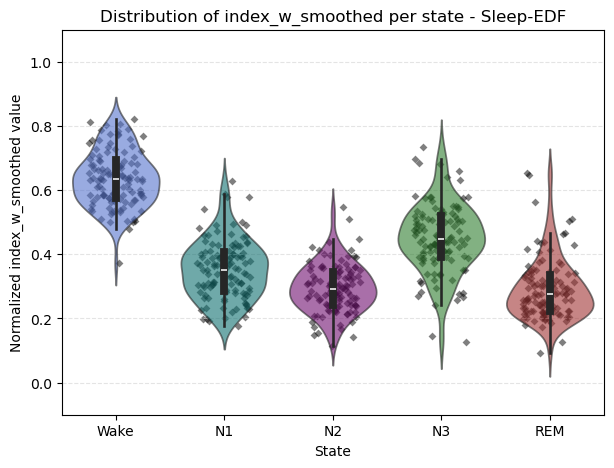

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


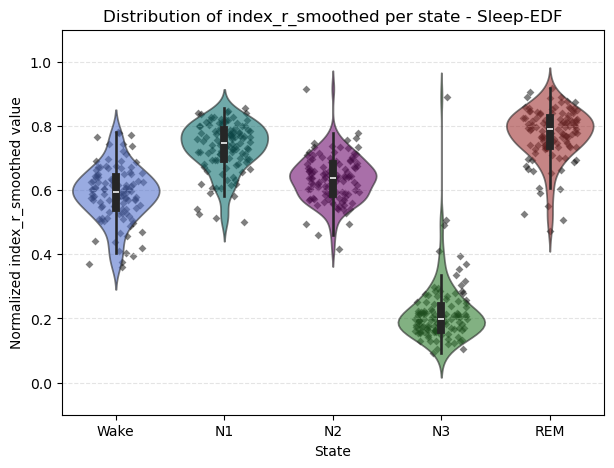

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


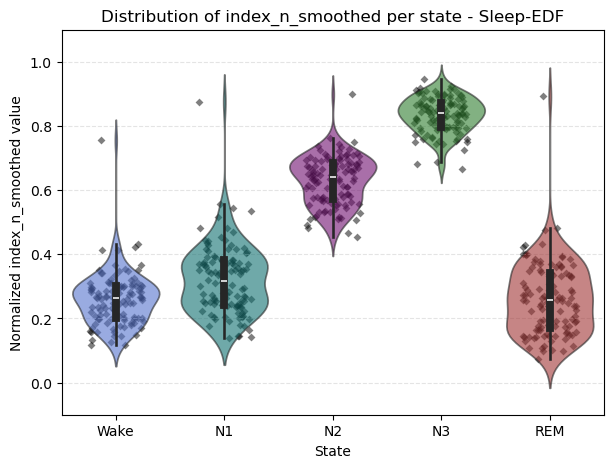

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


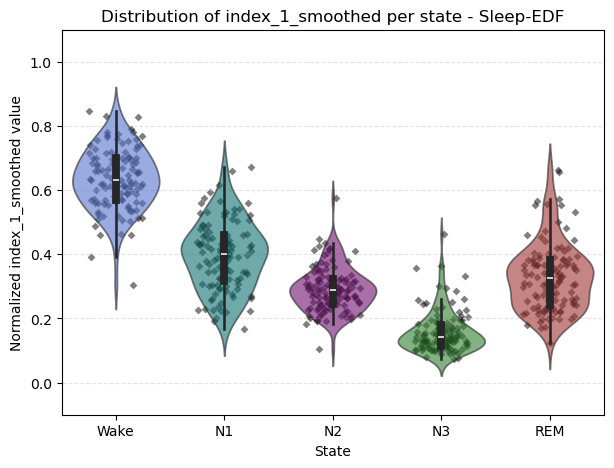

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


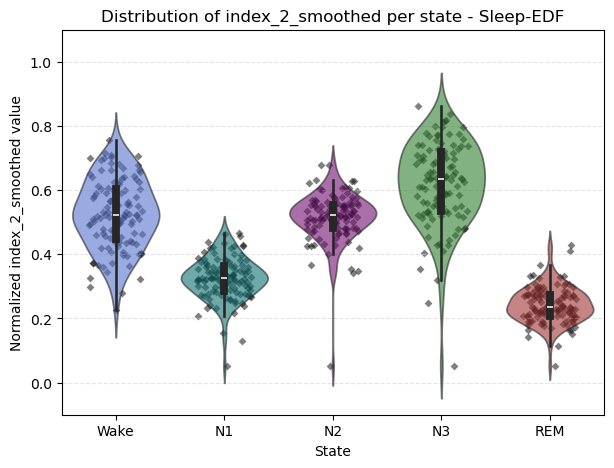

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


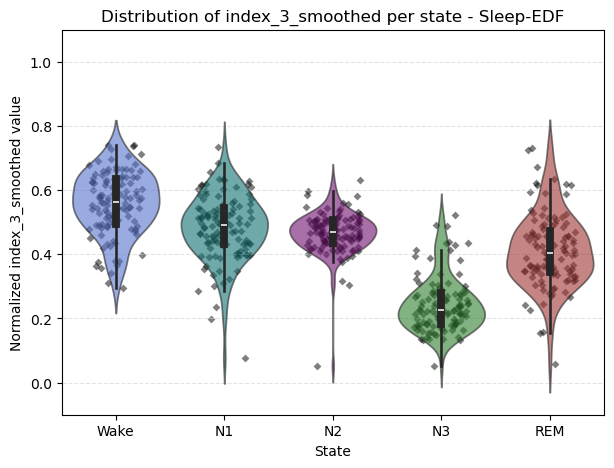

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


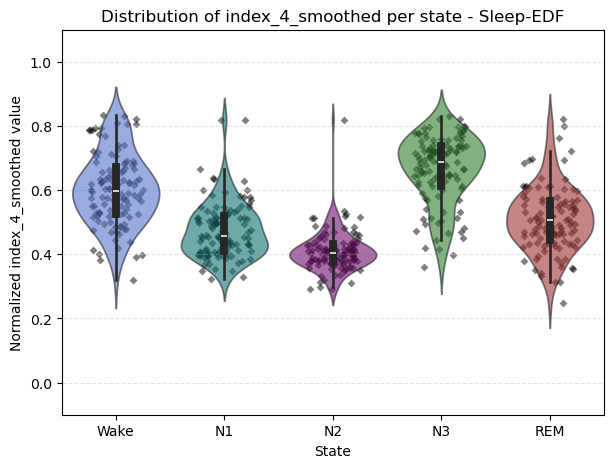

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


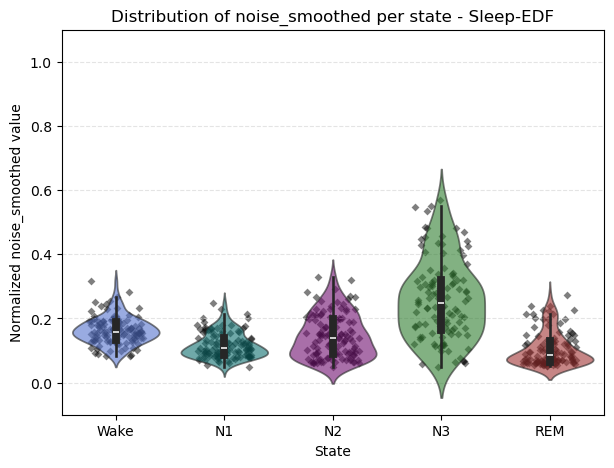

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


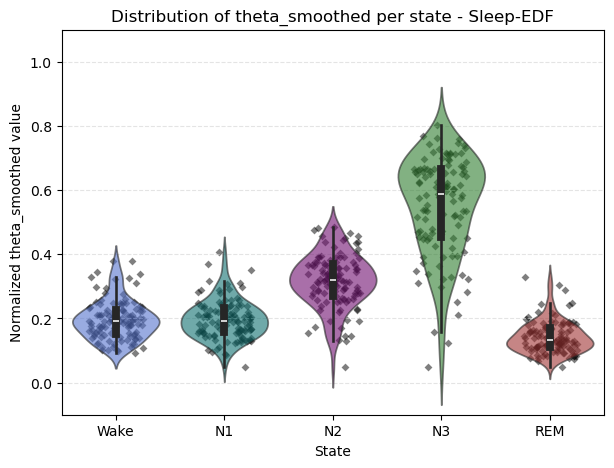

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


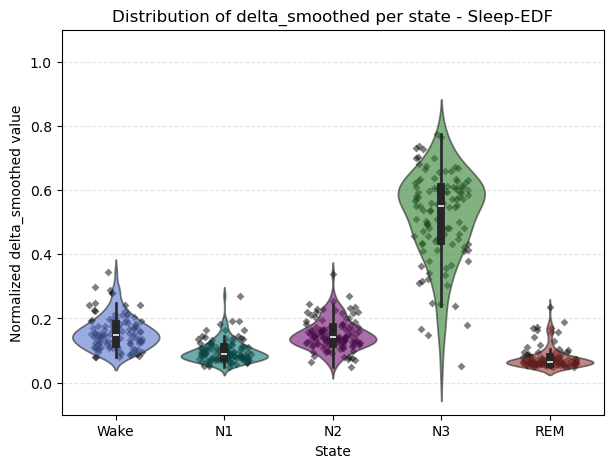

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


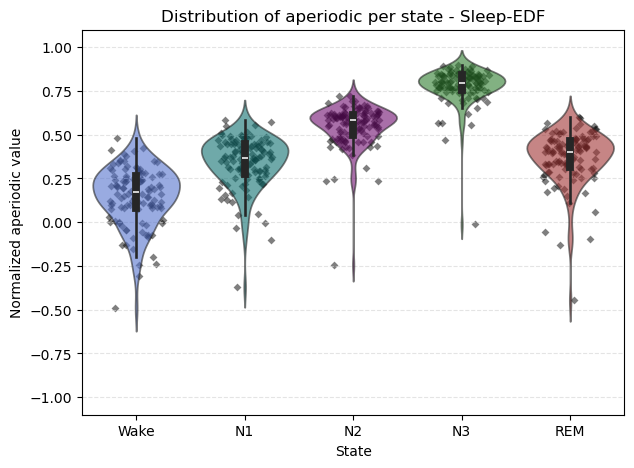

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


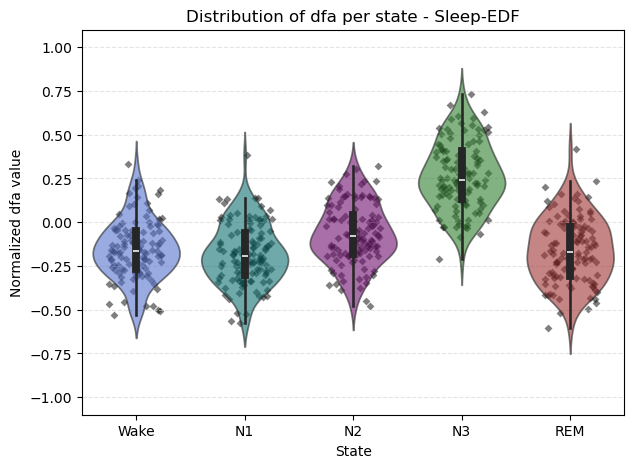

C:\Users\andri\AppData\Local\Temp\ipykernel_15184\4285266971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


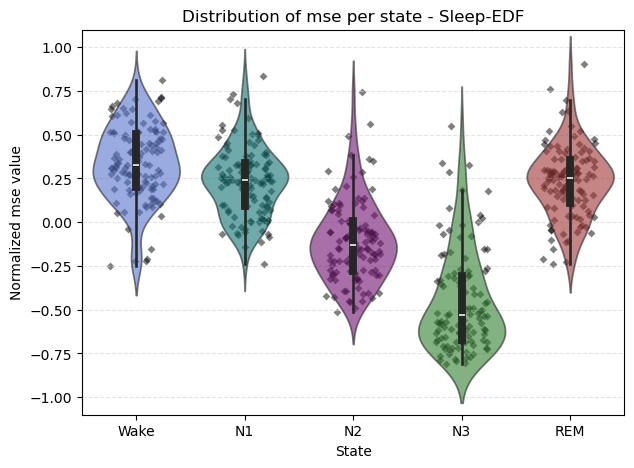

In [ ]:
# iterate features
for f_name, f_index in feature_dict.items():
    # get values from dictionary per feature
    df_feat = df[df["Feature"] == f_name]
    # violin visualization function
    features_violin(df_feat, f_name, wanted_keys, state_names, colors, title_id, file_id)

#### Barplots

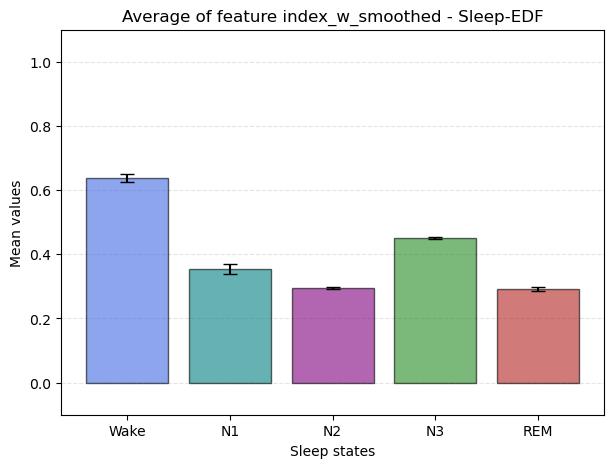

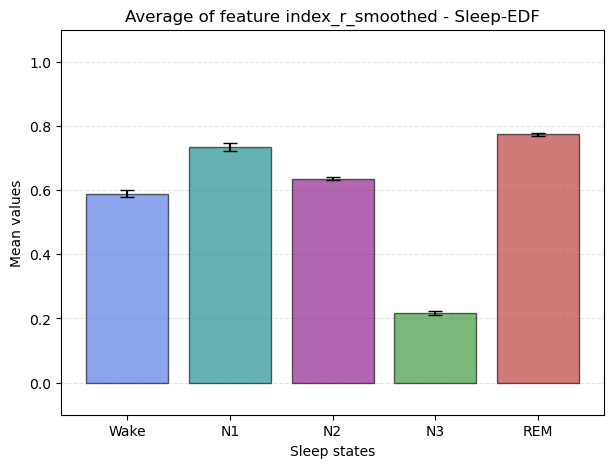

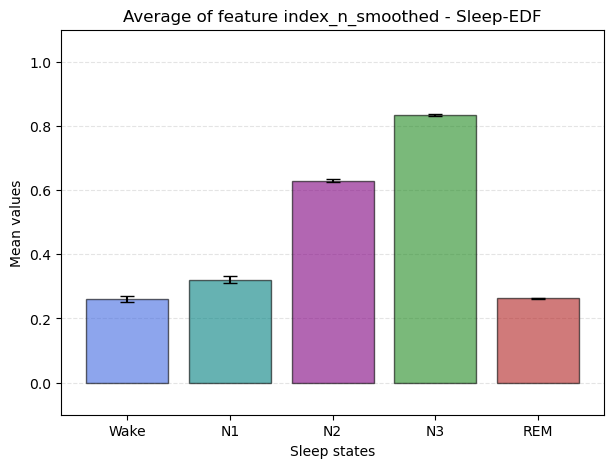

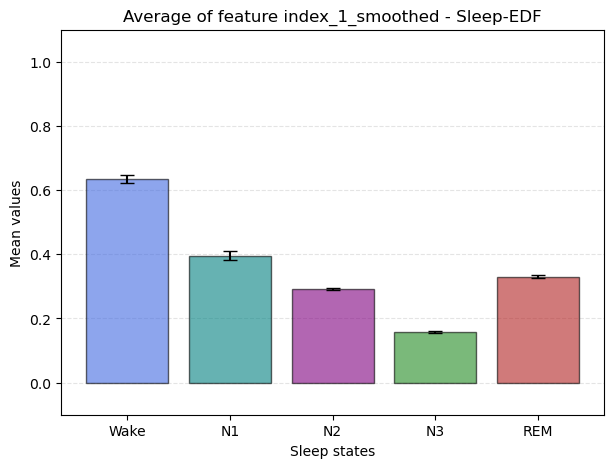

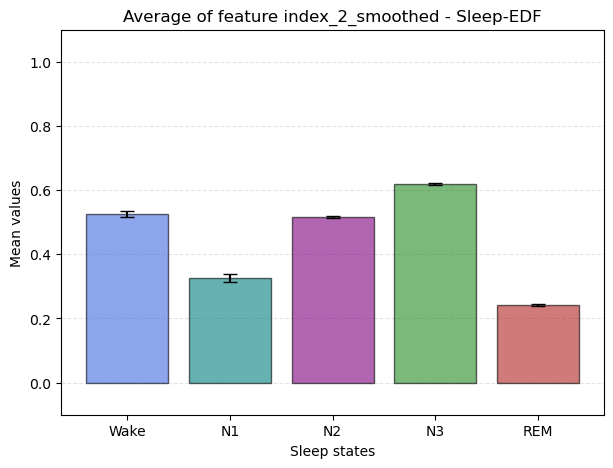

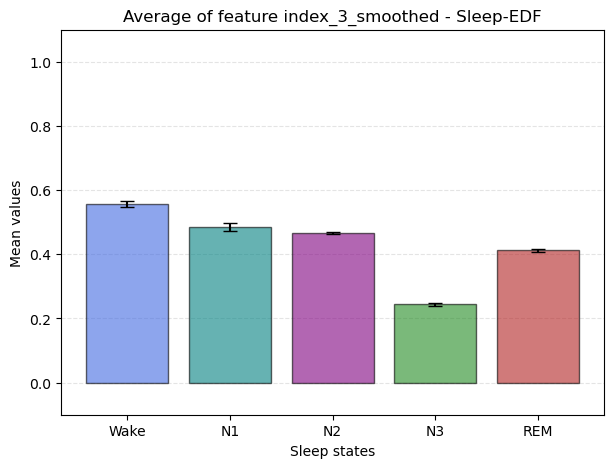

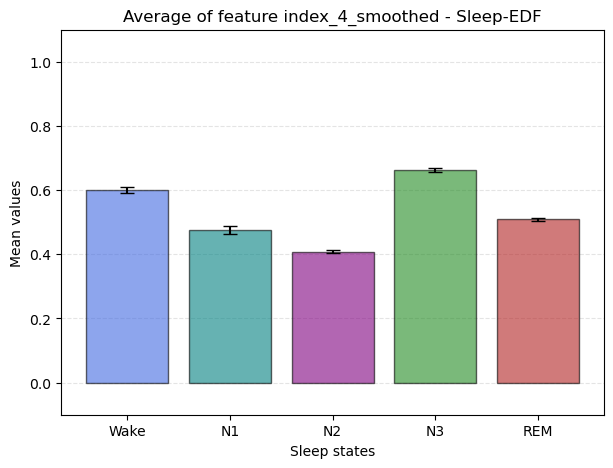

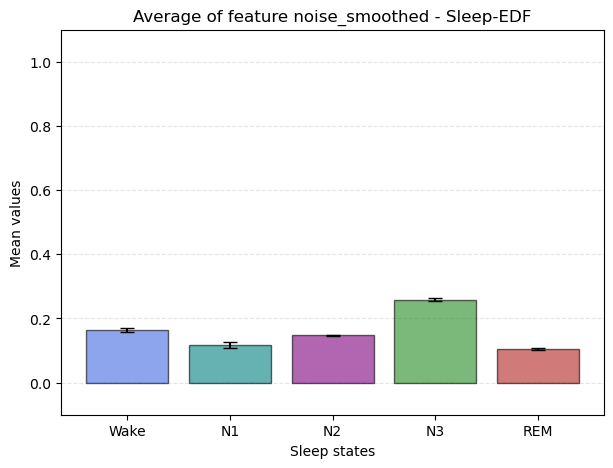

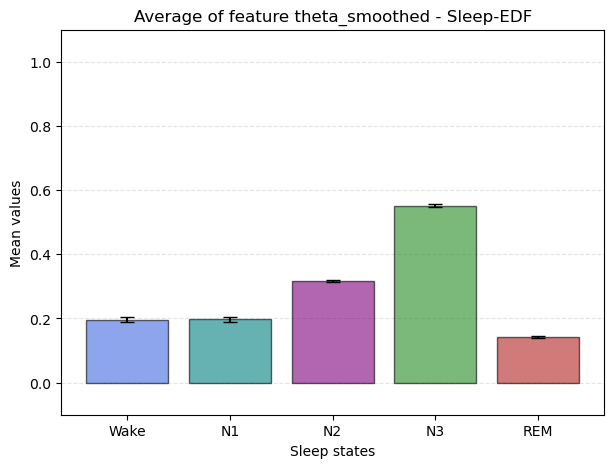

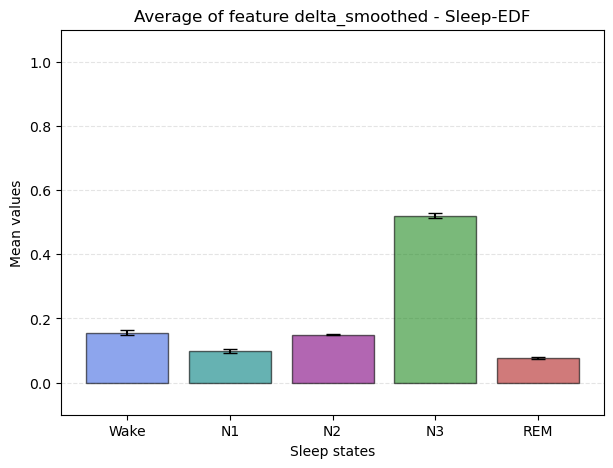

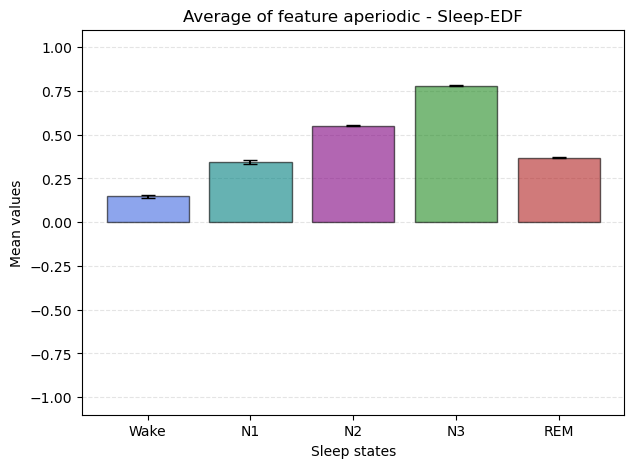

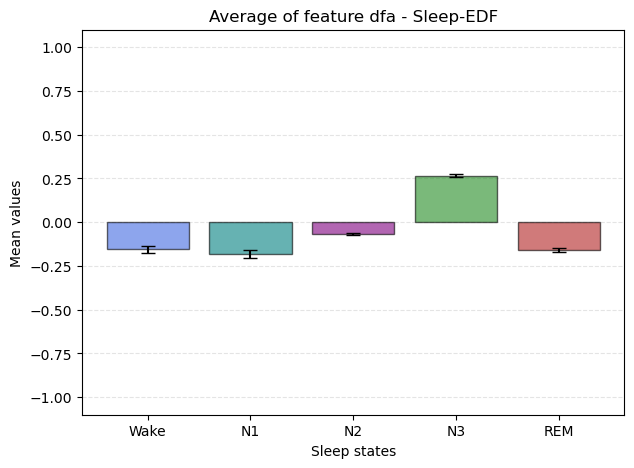

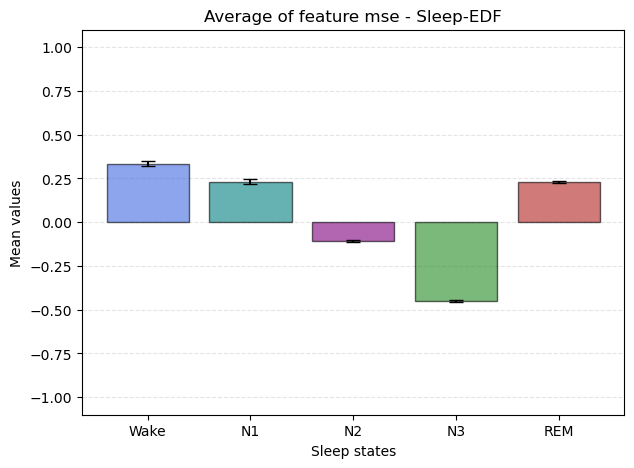

In [ ]:
# iterate features
for f_name, f_index in feature_dict.items():
    # barplot visualization function
    visualize_features(total_average, total_sem, f_name, f_index, colors, state_names, title_id, file_id)